### Daniel González Millán

## Executive Summary

This analysis identifies key patterns in the Madrid real estate market based on more than 100,000 properties. Areas with investment potential are identified, features that influence price (such as a terrace, elevator, or property condition) are analyzed, and a predictive model is proposed to estimate a property's target price. 


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import folium
from folium.plugins import MarkerCluster
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
df = pd.read_parquet('technical_interview.parquet')

In [5]:
print(df.head())

                                          ad_url  reference_id property_type  \
0  https://www.idealista.com/inmueble/102834499/     102834499      vivienda   
1  https://www.idealista.com/inmueble/105893546/     105893546     viviendas   
2  https://www.idealista.com/inmueble/103962048/     103962048     viviendas   
3  https://www.idealista.com/inmueble/104707721/     104707721      vivienda   
4  https://www.idealista.com/inmueble/105865316/     105865316     viviendas   

                                            ad_title  \
0  Alquiler de Piso en calle del Amparo, Lavapiés...   
1        Piso en venta en Arapiles, Chamberí, Madrid   
2   Chalet pareado en venta en Coimbra - Guadarra...   
3  Piso en venta en calle de Campo Real, Berrugue...   
4  Piso en venta en avenida de la Reina Victoria,...   

                                      ad_description transaction_type  \
0  UBK-493404(Disponible 1-11 meses) - Sin posibi...         alquiler   
1  Exclusivo piso exterior en Arapil

In [6]:
df.count()

ad_url                            200000
reference_id                      200000
property_type                     200000
ad_title                          200000
ad_description                    197451
transaction_type                  200000
n_rooms                           193699
n_baths                           196736
area                              198148
floor                             156878
has_elevator                      200000
has_terrace                       200000
is_exterior                       199431
has_swimming_pool                 200000
has_parking                       200000
has_garden                        200000
energy_certificate_consumption     30737
energy_certificate_emissions       26743
energy_certificate_state          196339
has_energy_certificate            200000
has_floorplan                     200000
has_virtual_tour                  200000
n_videos                          200000
property_state                    195894
latitude        

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ad_url                          200000 non-null  object 
 1   reference_id                    200000 non-null  int64  
 2   property_type                   200000 non-null  object 
 3   ad_title                        200000 non-null  object 
 4   ad_description                  197451 non-null  object 
 5   transaction_type                200000 non-null  object 
 6   n_rooms                         193699 non-null  float64
 7   n_baths                         196736 non-null  float64
 8   area                            198148 non-null  float64
 9   floor                           156878 non-null  float64
 10  has_elevator                    200000 non-null  bool   
 11  has_terrace                     200000 non-null  bool   
 12  is_exterior     

In this initial step, we select the key variables that will likely drive our analysis,
including property location, pricing, physical characteristics, condition, energy certification,
visibility (media), and the date when the property was viewed.

We will then calculate the percentage of missing values to understand data quality issues 
that may require imputation, filtering, or special treatment.

In [9]:
unique_values_province = df['province'].unique()
print(f"Valores únicos de province: {unique_values_province}")

unique_values_country = df['country'].unique()
print(f"Valores únicos de country: {unique_values_country}")

unique_values_country_code = df['country_code'].unique()
print(f"Valores únicos de country_code: {unique_values_country_code}")

unique_values_state = df['state'].unique()
print(f"Valores únicos de state: {unique_values_state}")

Valores únicos de province: ['Madrid' None 'Toledo' 'Guipúzcoa' 'Ávila']
Valores únicos de country: ['España']
Valores únicos de country_code: ['es']
Valores únicos de state: ['Comunidad de Madrid' 'Castilla-La Mancha']


"All data was filtered to include only listings within the city of Madrid, excluding nearby provinces and autonomous communities."

In [11]:
# Select key columns
columns_of_interest = [
    'city', 'state', 'district', 'quarter', 'latitude', 'longitude',
    'price', 'price_down_from', 'viewed_at', 'has_elevator',
    'n_baths', 'area', 'property_type', 'floor',
    'has_energy_certificate', 'energy_certificate_state',
    'has_floorplan', 'has_virtual_tour', 'n_videos',
    'has_garden', 'has_parking', 'has_swimming_pool',
    'has_terrace', 'has_virtual_tour', 'is_exterior', 'n_rooms',
    'n_videos', 'property_state', 'reference_id'
]

# Compute percentage of missing values
missing_percent = df[columns_of_interest].isnull().mean().sort_values(ascending=False) * 100

# Display missing percentages
missing_percent.round(2)

price_down_from             95.83
quarter                     25.08
floor                       21.56
district                     9.59
n_rooms                      3.15
property_state               2.05
energy_certificate_state     1.83
n_baths                      1.63
area                         0.93
is_exterior                  0.28
city                         0.00
has_parking                  0.00
has_swimming_pool            0.00
has_virtual_tour             0.00
has_terrace                  0.00
n_videos                     0.00
n_videos                     0.00
has_garden                   0.00
has_energy_certificate       0.00
has_virtual_tour             0.00
has_floorplan                0.00
state                        0.00
property_type                0.00
has_elevator                 0.00
viewed_at                    0.00
price                        0.00
longitude                    0.00
latitude                     0.00
reference_id                 0.00
dtype: float64

Based on the missing value percentages, we can now define a cleaning strategy:

- `price`, `latitude`, `longitude`, `city`, `property_type`, and media-related columns (e.g. `has_virtual_tour`) are fully complete — we can use them directly.
-  `price_down_from` is missing in 95.8% of cases, making it unreliable. We'll drop it.
- `quarter`, `floor`, and `district` have moderate levels of missingness. We may:
  - Use them cautiously in analyses where geospatial detail is essential,
  - Consider imputing or grouping by broader geographies (`district` > `quarter`).
-  Minor missingness in `n_rooms`, `n_baths`, `area`, `property_state`, and `energy_certificate_state` — we will drop rows with missing values in these, as the proportion is low and imputation would add noise.

We proceed to apply this cleaning strategy next.

In [13]:
"""
Drop column with excessive missing values ('price_down_from'),
and remove rows with missing values in essential numeric and categorical fields.
"""

# Drop 'price_down_from' due to excessive missing data
df_cleaned = df.drop(columns=['price_down_from'])

# Drop rows with missing values in key fields
required_fields = ['n_rooms', 'n_baths', 'area', 'property_state', 'energy_certificate_state']
df_cleaned = df_cleaned.dropna(subset=required_fields)


df_cleaned.reset_index(drop=True, inplace=True)
df_cleaned.shape

(192786, 38)

In [14]:
# Filter by Comunidad de Madrid and ciudad de Madrid
df_madrid = df_cleaned[
    (df_cleaned['state'] == 'Comunidad de Madrid') &
    (df_cleaned['city'].str.lower() == 'madrid')
].copy()

print(f"Listings remaining after filtering to Madrid city: {df_madrid.shape[0]}")

Listings remaining after filtering to Madrid city: 141010


### Analyze property price distribution

In this step, we take a closer look at the price variable to understand the range of values, detect potential outliers, and assess its overall distribution. 

We will start with basic summary statistics and a histogram.

In [16]:
# Summary statistics
df_madrid['price'].describe().apply(lambda x: round(x, 2))

count      141010.00
mean       579875.70
std        929933.33
min           490.00
25%          3000.00
50%        262000.00
75%        739000.00
max      23000000.00
Name: price, dtype: float64

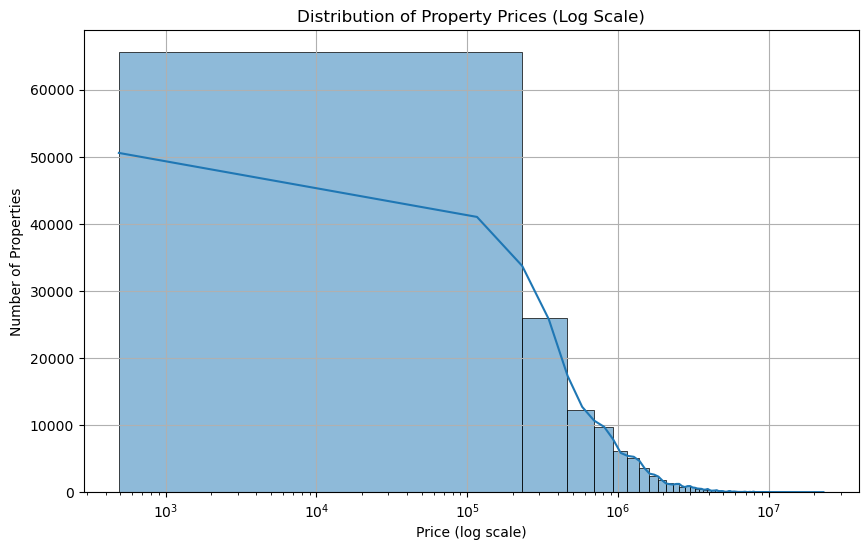

In [17]:
# Histogram (log scale to reduce skewness)
plt.figure(figsize=(10, 6))
sns.histplot(df_madrid['price'], bins=100, kde=True)
plt.xscale('log')
plt.title('Distribution of Property Prices (Log Scale)')
plt.xlabel('Price (log scale)')
plt.ylabel('Number of Properties')
plt.grid(True)
plt.show()

###  Price Insights

- The **mean price** is ~593,000€, but the **median** is ~280,000€, indicating a **right-skewed distribution** due to high-value properties.
- The **minimum price** is extremely low (440€), which is likely a data entry error or placeholder.
- The **maximum price** is 23 million euros — likely luxury listings or commercial real estate.
- 25% of listings are priced under ~6,300€, suggesting many potential outliers or incorrect listings.

This confirms the need to:
1. Visualize the distribution (log scale is appropriate),
2. Potentially **filter out unrealistic prices** before comparing across locations.

In [19]:
"""
As we have a lot of unrealistic values, we are going to check other variables to see if they are directly related to those prices and
we can filter through them.
We will explore listings with prices under €20,000 to check if they correspond to non-residential
units (e.g., garages, storage rooms), partial ownership, or data errors.
"""

df_low_price = df_madrid[df_madrid['price'] < 20000]

# Quick look at property types and descriptions
df_low_price[['price', 'property_type', 'transaction_type', 'n_rooms', 'area', 'property_state']].sample(10)


,price,property_type,transaction_type,n_rooms,area,property_state
50686,1150.0,viviendas,alquiler,1.0,70.0,Buen estado
99919,1483.0,vivienda,rent,0.0,28.0,Buen estado
176057,3950.0,viviendas,alquiler,3.0,194.0,Buen estado
181835,3500.0,viviendas,alquiler,3.0,160.0,Buen estado
148509,1400.0,vivienda,rent,2.0,50.0,Buen estado
43534,1400.0,viviendas,rent,2.0,80.0,Buen estado
58673,800.0,viviendas,alquiler,1.0,33.0,Buen estado
56824,815.0,viviendas,rent,1.0,60.0,Buen estado
66904,1425.0,vivienda,alquiler,1.0,47.0,Obra nueva
26386,2000.0,vivienda,rent,2.0,120.0,Buen estado


### Keep only sale listings

The dataset includes both rental and sale listings. Since investment decisions regarding 
real estate purchases focus on sale properties, we remove all rental entries.

We filter based on the `transaction_type` column, which contains both Spanish and English variants (e.g., 'venta', 'sale').


In [21]:
# Check unique transaction types
print(df_madrid['transaction_type'].unique())

# Define valid values for sales
sale_types = ['venta', 'sale']

# Filter only sale listings
df_sale = df_madrid[df_madrid['transaction_type'].str.lower().isin(sale_types)].copy()

# Reset index and show shape
df_sale.reset_index(drop=True, inplace=True)
df_sale.shape

['alquiler' 'buy' 'venta' 'rent']


(48905, 38)

### Reinspect price distribution after removing rental listings

Now that we are only considering properties for sale, we revisit the price distribution 
to check for remaining outliers or extreme luxury properties. This will help us decide 
on optional filtering thresholds.

In [23]:
# Summary statistics for sale listings
df_sale['price'].describe().apply(lambda x: round(x, 2))

count       48905.00
mean       837076.75
std       1029046.97
min         12000.00
25%        245000.00
50%        470000.00
75%        999999.00
max      23000000.00
Name: price, dtype: float64

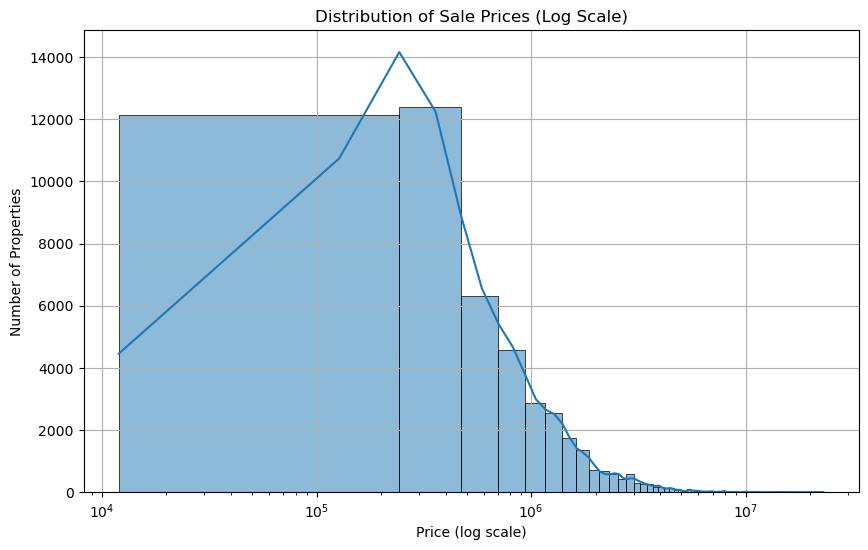

In [24]:
# Histogram (log scale again)
plt.figure(figsize=(10, 6))
sns.histplot(df_sale['price'], bins=100, kde=True)
plt.xscale('log')
plt.title('Distribution of Sale Prices (Log Scale)')
plt.xlabel('Price (log scale)')
plt.ylabel('Number of Properties')
plt.grid(True)
plt.show()

### Create price per square meter (€/m²)

To make prices comparable across properties of different sizes,
we create a new column that measures the price per square meter.
This will be our primary metric for detecting over- or under-valued areas.


In [26]:
# Create price per square meter
df_sale['price_per_m2'] = df_sale['price'] / df_sale['area']

# Check basic stats
df_sale['price_per_m2'].describe().apply(lambda x: round(x, 2))

count    48905.00
mean      5553.86
std       3125.43
min         33.21
25%       3245.45
50%       4818.18
75%       7153.85
max      44069.77
Name: price_per_m2, dtype: float64

### Explore property types

Before calculating metrics like price per square meter,
we examine the `property_type` column to see what kinds of properties are included in the dataset.

This helps identify and optionally exclude non-residential listings (e.g., garages, commercial properties).
python
Copiar
Editar


In [28]:
# Count of property types
df_sale['property_type'].value_counts()

property_type
vivienda     24464
viviendas    24441
Name: count, dtype: int64

In [29]:
# Quick look at titles
df_sale['ad_title'].sample(10)

43674    Piso en venta en calle de José Ortega y Gasset...
2052      Casa o chalet en venta en calle de Cestona, O...
5613     Piso en venta en Dulcinea, Cuatro Caminos, Madrid
36090           Piso en venta en juan bravo, Lista, Madrid
22528    Piso en venta en Pau de Carabanchel, Carabanch...
13558    Piso en venta en calle de Vélez Rubio, 133, Ap...
39906      Piso en venta en Cuatro Caminos, Tetuán, Madrid
32385    Piso en venta en calle Fernando Díaz de Mendoz...
23044    Piso en venta en calle de Sotomayor, Valleherm...
39822    Ático en venta en calle del Príncipe de Vergar...
Name: ad_title, dtype: object

### Extract property subtype from ad title

The column `ad_title` usually starts with the type of property (e.g., "Piso en venta…", "Casa o chalet…").
We extract the first word (or phrase) to create a more informative `property_subtype` variable.


In [31]:
# Extract first part before "en venta" or similar
df_sale['property_subtype'] = df_sale['ad_title'].str.extract(r'^(.+?)\s+en\s+venta', expand=False)

# Normalize and strip
df_sale['property_subtype'] = df_sale['property_subtype'].str.lower().str.strip()

# View unique subtypes and their counts
df_sale['property_subtype'].value_counts().head(20)

property_subtype
piso                           39772
ático                           2760
dúplex                          1730
casa o chalet independiente     1383
estudio                         1276
chalet adosado                  1047
chalet pareado                   843
casa o chalet                     93
casa rural                         1
Name: count, dtype: int64

### Investigate low-price properties by property subtype

Before applying filters or grouping types, we explore the bottom-priced listings
to check if specific subtypes are systematically associated with unusually low prices.

In [33]:
# Sort by price ascending
df_sale[['price', 'area', 'price_per_m2', 'property_subtype']].sort_values('price').head(30)

,price,area,price_per_m2,property_subtype
11619,12000.0,61.0,196.721311,piso
2878,12000.0,61.0,196.721311,piso
38829,12000.0,61.0,196.721311,piso
5072,26100.0,59.0,442.372881,piso
33781,26100.0,59.0,442.372881,piso
27034,26100.0,59.0,442.372881,piso
42306,26100.0,59.0,442.372881,piso
19192,33500.0,51.0,656.862745,piso
4179,33500.0,25.0,1340.000000,piso
4428,35000.0,98.0,357.142857,piso


## Summary of Data Cleaning and Property Type Exploration

After exploring and validating the dataset, we reached the following key conclusions:

1. **Rental vs Sale Listings**  
   - Many properties with unusually low prices turned out to be rental listings.
   - We filtered the dataset to retain only properties for **sale**, resulting in 48,905 relevant listings.

2. **Price Distribution after Filtering**  
   - Even after filtering rentals, the price distribution remains heavily right-skewed, with some properties priced above €20M.
   - The **median sale price** is ~€445,000, while the **mean** is ~€800,000, indicating the presence of luxury listings.

3. **Property Type Normalization**  
   - The `property_type` column only included two inconsistent labels: `'vivienda'` and `'viviendas'`. We normalized them.
   - We then extracted the **true property subtype** from the `ad_title` (e.g., `'piso'`, `'ático'`, `'chalet adosado'`), creating a new column: `property_subtype`.

4. **Subtype Distribution**  
   - The dataset contains a healthy mix of property types:  
     - `piso` (71%), `chalet adosado`, `ático`, `dúplex`, `estudio`, etc.  
     - Only a small fraction (<2%) corresponds to `finca rústica`, `casa rural`, or other rare types.

5. **Investigation of Low-Price Properties**  
   - A manual inspection showed that low-price properties (e.g., < €40,000) mostly consist of **valid small apartments** (`piso`) with realistic price-per-square-meter values (e.g., €400–€1,000/m²).
   - Therefore, we decided **not to remove these listings**, as they could represent legitimate investment opportunities.

 We are now ready to move on to a price-per-square-meter analysis across Madrid's districts.


### Analyze price per square meter by district

We group the data by `district` and calculate average and median price per square meter.
This gives us an overview of the relative pricing across different areas of Madrid.

In [36]:
# Group by district
district_prices = (
    df_sale.groupby('district')['price_per_m2']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('mean')
    .round(2)
)

district_prices.head(10)  # Show cheapest districts

,count,mean,median,min,max
district,,,,,
Villaverde,1580,2301.92,2229.73,442.37,20833.33
Barrio de La Estación,5,2602.38,2563.16,2368.42,2855.95
Puente de Vallecas,2731,2654.50,2500.00,141.18,14444.44
Usera,1262,2894.62,2693.73,805.83,18479.17
Carabanchel,2715,2920.58,2809.52,33.21,13640.78
Villa de Vallecas,1014,2984.41,2971.12,398.37,6500.00
Vicálvaro,1048,3067.66,3103.23,1277.14,9900.00
Latina,1698,3107.89,3015.87,566.48,7723.58
Moratalaz,459,3303.58,3191.49,1034.48,6249.84


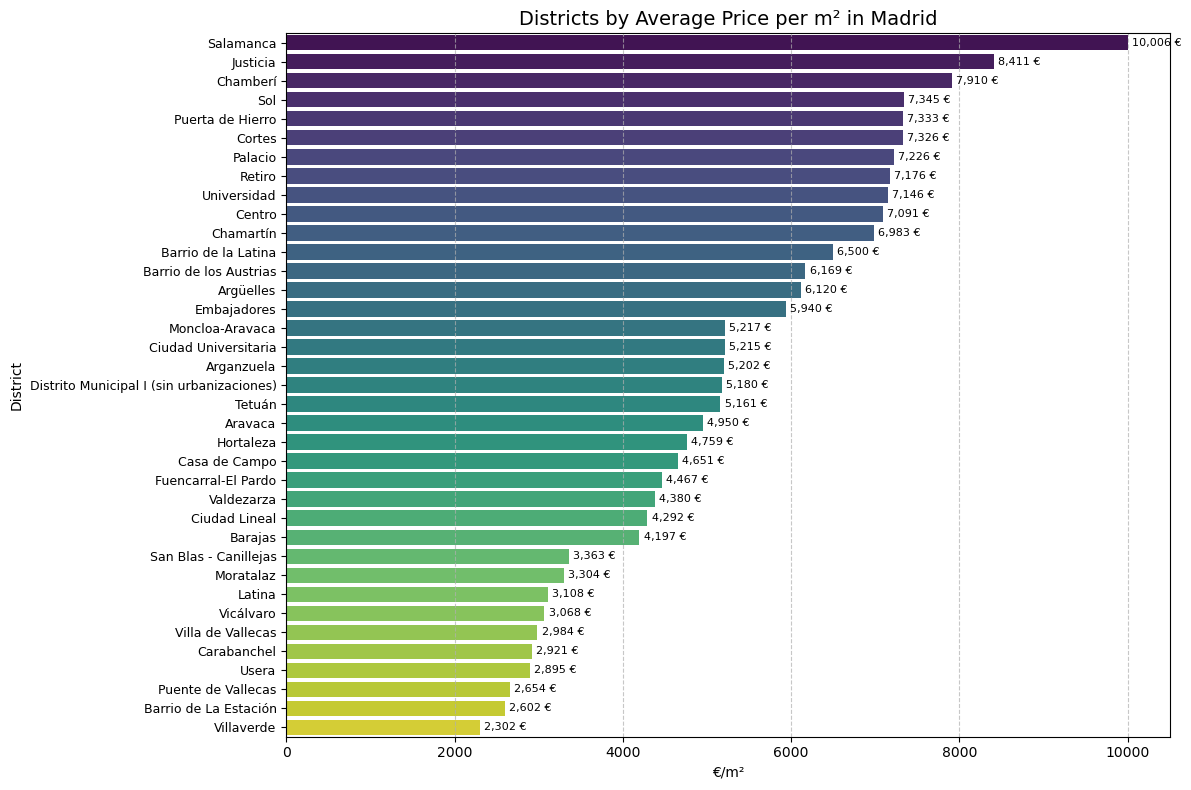

In [37]:
filtered_df = district_prices.sort_values(by='mean', ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(
    data=filtered_df,
    x='mean',
    y='district',
    hue='district', 
    palette='viridis'
)

plt.title('Districts by Average Price per m² in Madrid', fontsize=14)
plt.xlabel('€/m²')
plt.ylabel('District')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tick_params(axis='y', labelsize=9)

# Añadir etiquetas con valores
for i, v in enumerate(filtered_df['mean']):
    plt.text(v + 50, i, f"{v:,.0f} €", va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [38]:
# Group by districts with at least 30 listings
valid_districts = (
    df_sale['district'].value_counts()
    [df_sale['district'].value_counts() >= 30]
    .index
)

# Enriched grouping by district
district_summary = (
    df_sale[df_sale['district'].isin(valid_districts)]
    .groupby('district')
    .agg({
        'price_per_m2': 'mean',
        'property_state': lambda x: (x == 'Buen estado').mean(),
        'n_rooms': 'mean',
        'n_baths': 'mean',
        'area': 'mean',
        'floor': 'mean',
        'has_elevator': 'mean',
        'has_terrace': 'mean',
        'is_exterior': lambda x: x.astype(str).str.lower().eq('true').mean(),
        'has_parking': 'mean',
        'has_garden': 'mean',
        'has_swimming_pool': 'mean',
        'has_floorplan': 'mean',
        'has_virtual_tour': 'mean',
        'n_videos': 'mean',
        'has_energy_certificate': 'mean',
        'reference_id': 'count'
    })
    .rename(columns={
        'price_per_m2': 'Avg €/m²',
        'property_state': '% in Good Condition',
        'n_rooms': 'Avg Rooms',
        'n_baths': 'Avg Baths',
        'area': 'Avg Area (m²)',
        'floor': 'Avg Floor',
        'has_elevator': '% with Elevator',
        'has_terrace': '% with Terrace',
        'is_exterior': '% Exterior',
        'has_parking': '% with Parking',
        'has_garden': '% with Garden',
        'has_swimming_pool': '% with Pool',
        'has_floorplan': '% with Floorplan',
        'has_virtual_tour': '% with Virtual Tour',
        'n_videos': 'Avg Videos',
        'has_energy_certificate': '% with Energy Cert.',
        'reference_id': 'Listings Count'
    })
    .round(2)
)

In [39]:
# Table sorted by price per m² (cheapest at the top)
cols_to_show = [
    'Avg €/m²',
    'Avg Area (m²)',
    'Avg Rooms',
    '% in Good Condition',
    '% with Elevator',
    '% with Floorplan',
    '% with Virtual Tour',
    'Listings Count'
]

display(district_summary[cols_to_show].sort_values('Avg €/m²', ascending=True))

,Avg €/m²,Avg Area (m²),Avg Rooms,% in Good Condition,% with Elevator,% with Floorplan,% with Virtual Tour,Listings Count
district,,,,,,,,
Villaverde,2301.92,77.36,2.46,0.79,0.43,0.29,0.04,1580
Puente de Vallecas,2654.50,72.66,2.23,0.77,0.41,0.25,0.05,2731
Usera,2894.62,84.37,2.50,0.81,0.48,0.32,0.10,1262
Carabanchel,2920.58,96.36,2.46,0.76,0.52,0.33,0.08,2715
Villa de Vallecas,2984.41,99.56,2.37,0.76,0.73,0.42,0.06,1014
Vicálvaro,3067.66,110.25,2.73,0.42,0.73,0.67,0.03,1048
Latina,3107.89,84.84,2.59,0.80,0.59,0.27,0.07,1698
Moratalaz,3303.58,87.75,2.81,0.87,0.66,0.25,0.08,459
San Blas - Canillejas,3363.39,107.75,2.45,0.78,0.61,0.35,0.10,1925


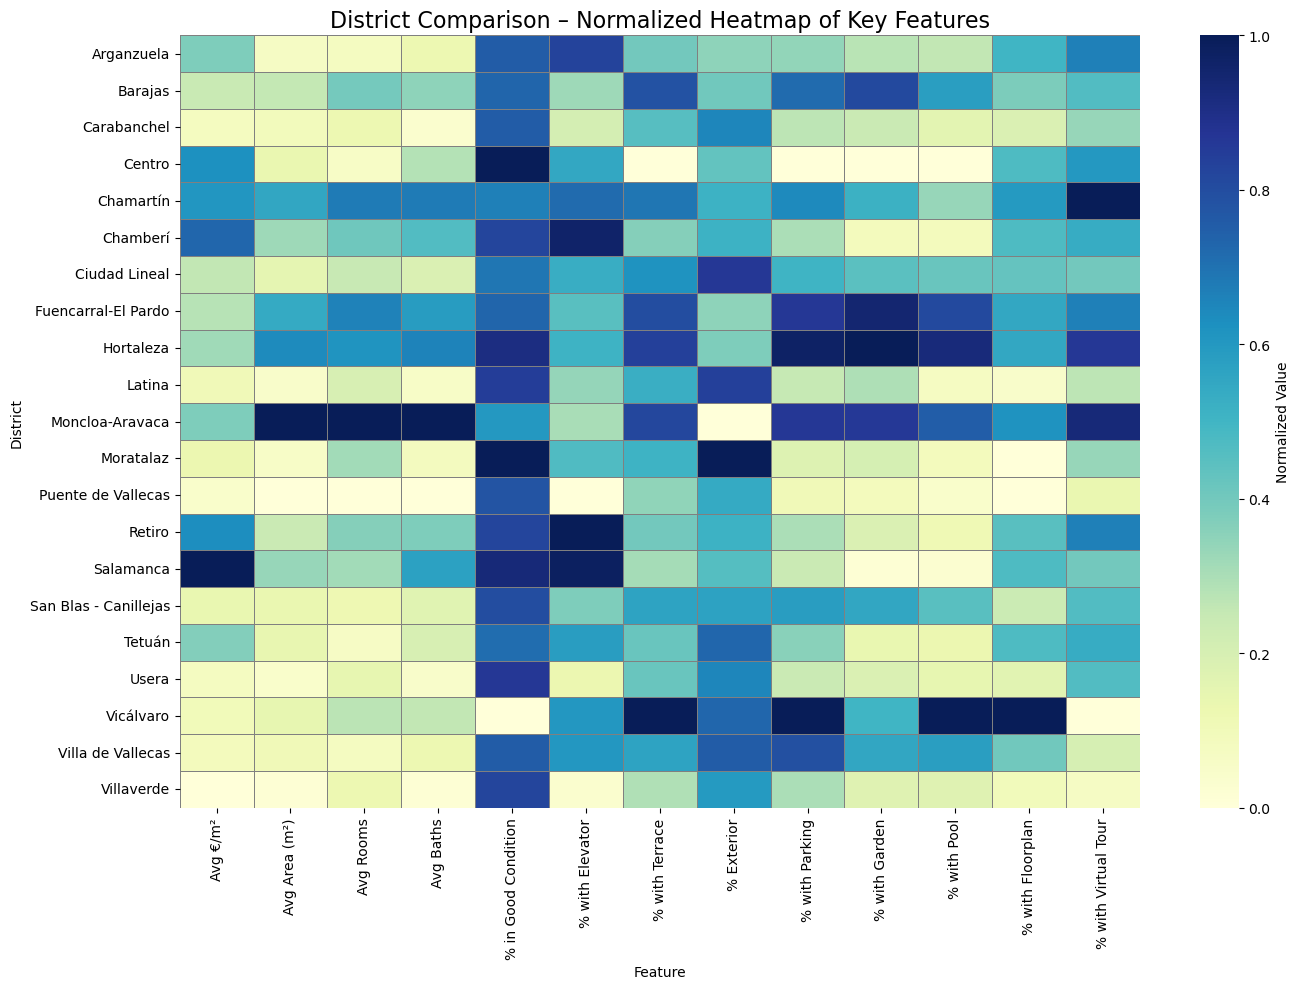

In [40]:
# Selecting normalized variables for the heatmap
heatmap_vars = [
    'Avg €/m²',
    'Avg Area (m²)',
    'Avg Rooms',
    'Avg Baths',
    '% in Good Condition',
    '% with Elevator',
    '% with Terrace',
    '% Exterior',
    '% with Parking',
    '% with Garden',
    '% with Pool',
    '% with Floorplan',
    '% with Virtual Tour',
    '% with Energy Cert.'
]

# Subset and normalization between 0 and 1 for visualization
heatmap_data = district_summary[heatmap_vars].copy()
heatmap_data_filtered = heatmap_data.loc[:, heatmap_data.nunique() > 1]
heatmap_data_norm = (heatmap_data_filtered - heatmap_data_filtered.min()) / (heatmap_data_filtered.max() - heatmap_data_filtered.min())


# Plot
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data_norm,
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Normalized Value'},
    annot=False
)
plt.title('District Comparison – Normalized Heatmap of Key Features', fontsize=16)
plt.xlabel('Feature')
plt.ylabel('District')
plt.tight_layout()
plt.show()

## Strategic Insights by District (Heatmap + Metric Table Summary)

The following conclusions are drawn from a combined analysis of a normalized heatmap and a metric comparison table across the 21 districts of Madrid capital (filtered for listings ≥30):

---

### Best Price-to-Quality Opportunities

- **Villaverde**  
  -  **Lowest €/m² (2,301 €)**  
  -  79% in good condition, 43% with elevator  
  -  Weak digital visibility, but high supply (1,580 listings)  
  -  Great target for high-yield, low-entry investments

- **Usera**  
  -  84 m² on average, 2.5 rooms  
  -  81% in good condition, better digital presence (10% tours, 32% floorplans)  
  -  Balanced, undervalued district with upside

- **Carabanchel**  
  -  96 m², 76% in good condition, fair visibility  
  -  Suitable for affordable acquisition with moderate comfort

---

### Best for Comfort + Large Units

- **Villa de Vallecas**  
  -  99 m², 2.4 rooms  
  -  73% elevator, 42% with floorplans  
  -  Good for families or long-term rental

- **Vicálvaro**  
  -  110 m², 67% floorplan presence  
  -  Only 42% in good condition → potential under development  
  -  Use with filtering by renovation status

---

### High-End, High-Visibility Districts

- **Retiro, Chamberí, Salamanca**  
  - €7,000–€10,000 €/m²  
  -  +90% elevator, high floorplan coverage  
  - Best suited for flipping, premium rentals or repositioning

---

###  Districts to Monitor Closely

- **Puente de Vallecas**  
  -  Good supply & low €/m²  
  -  Weak digital presence & average condition  
  -  Requires careful property-level filtering

- **Vicálvaro**  
  - Low condition rate (42%) may mask newer supply or poor upkeep  
  - Proceed with careful segmentation

---

### Summary Table

| Category                          | Top Districts                          |
|-----------------------------------|----------------------------------------|
| Best Value for Money              | Villaverde, Usera, Carabanchel         |
| Spacious & Comfortable Units      | Villa de Vallecas, Vicálvaro           |
| High Visibility & Premium Targets | Retiro, Chamberí, Salamanca            |
| Requires Caution                  | Puente de Vallecas, Vicálvaro          |


From now on, we will try to find the best opportunities the market has, we are going to divide this opportunities in 4 groups

- A - "Absolute Bargain
- B – "Cheap in an expensive area"
- C – "Rental Yield"
- D – "Renovable with potential"
  
We are going to start defining the new metric __expected_price_m2__ that we will compare with the old one, __district_avg_price_m2__ so we can generate an __undervaluation_score__ that will allow us to measure if a certain property could be profitable.

In [43]:
# Base price is district average
df_sale['district_avg_price_m2'] = df_sale['district'].map(district_summary['Avg €/m²'])

# Bonus weights (puedes ajustarlos)
adj_price = df_sale['district_avg_price_m2'] * (
    1
    + 0.03 * (df_sale['n_rooms'].fillna(0) - df_sale['n_rooms'].mean()) / df_sale['n_rooms'].std()
    + 0.10 * df_sale['has_elevator']
    + 0.05 * df_sale['has_terrace']
    + 0.04 * df_sale['has_floorplan']
    + 0.08 * (df_sale['property_state'] == 'Buen estado')
)


In [44]:
df_sale['expected_price_m2'] = adj_price
df_sale['price_per_m2'] = df_sale['price'] / df_sale['area']
df_sale['undervaluation_score'] = df_sale['expected_price_m2'] - df_sale['price_per_m2']


### A - "Absolute Bargain"
**Definition:** Properties whose price per square meter is significantly below their expected value given their characteristics (rooms, condition, extras, digital visibility) and the district average.

**Objective:** Identify apartments clearly undervalued by the market..

**Estimation formula:**
    expected_price_m2 = district_avg_price_m2 * (1 + ajustes)

**Weights applied:**
- +10% if in "Good condition"
- +10% if it has an elevator
- +5% if it has a terrace
- +4% if it has a floor plan
- +3% if it has more rooms than average (adjusted by z-score)

**Final metric:**
    undervaluation_score = expected_price_m2 - actual_price_m2

    

In [46]:
df_sale['district_avg_price_m2'] = df_sale['district'].map(district_summary['Avg €/m²'])
room_z = (df_sale['n_rooms'] - df_sale['n_rooms'].mean()) / df_sale['n_rooms'].std()

adj_price_a = df_sale['district_avg_price_m2'] * (
    1
    + 0.10 * (df_sale['property_state'] == 'Buen estado')
    + 0.10 * df_sale['has_elevator']
    + 0.05 * df_sale['has_terrace']
    + 0.04 * df_sale['has_floorplan']
    + 0.03 * room_z.fillna(0)
)

# Calculate score A
df_sale['expected_price_m2_A'] = adj_price_a

df_sale['undervaluation_score_A'] = df_sale['expected_price_m2_A'] - df_sale['price_per_m2']

bargain = df_sale[
    (df_sale['undervaluation_score_A'] > 500) &
    (df_sale['price_per_m2'] < df_sale['expected_price_m2_A'])
].sort_values('undervaluation_score_A', ascending=False)

In [47]:
bargain[['district', 'price', 'area', 'price_per_m2', 'expected_price_m2_A', 'undervaluation_score_A', 'ad_url']].head(5)

,district,price,area,price_per_m2,expected_price_m2_A,undervaluation_score_A,ad_url
43418,Salamanca,445600.0,180.0,2475.555556,12661.282995,10185.727439,https://www.idealista.com/inmueble/106650751/
9881,Salamanca,650000.0,179.0,3631.284916,13672.541607,10041.256691,https://www.idealista.com/inmueble/103719385/
22726,Salamanca,475000.0,141.0,3368.794326,13358.120158,9989.325831,https://www.idealista.com/inmueble/100875918/
45346,Salamanca,475000.0,141.0,3368.794326,13358.120158,9989.325831,https://www.idealista.com/inmueble/100875918/
36060,Salamanca,1275000.0,402.0,3171.641791,12957.891758,9786.249967,https://www.idealista.com/inmueble/106445311/


### B – "Cheap in an expensive area"
**Definition:** Properties whose price per m² is much lower than the district average, but located in high-value areas (>P75).

**Objective:** Detect cheap apartments in Madrid's most expensive neighborhoods, ideal for flipping or premium rentals.

**Metric:**
    relative_discount = district_avg_price_m2 - actual_price_m2

**Conditions:**
- Only districts with €/m² > Q3 (p75) are considered
- Those with a difference of at least €1,000/m² are selected

In [49]:
p75_price = district_summary['Avg €/m²'].quantile(0.75)

expensive_area = df_sale[df_sale['district_avg_price_m2'] > p75_price].copy()
expensive_area['relative_discount'] = expensive_area['district_avg_price_m2'] - expensive_area['price_per_m2']

cheap_in_expensive_area = expensive_area[
    expensive_area['relative_discount'] > 1000
].sort_values('relative_discount', ascending=False)

In [50]:
cheap_in_expensive_area[['district', 'price', 'price_per_m2', 'district_avg_price_m2', 'relative_discount', 'ad_url']].head(5)

,district,price,price_per_m2,district_avg_price_m2,relative_discount,ad_url
4084,Salamanca,450000.0,2295.918367,10005.71,7709.791633,https://www.idealista.com/inmueble/106134038/
43418,Salamanca,445600.0,2475.555556,10005.71,7530.154444,https://www.idealista.com/inmueble/106650751/
20698,Salamanca,299000.0,2646.017699,10005.71,7359.692301,https://www.idealista.com/inmueble/104436782/
40413,Salamanca,190000.0,2714.285714,10005.71,7291.424286,https://www.idealista.com/inmueble/106392549/
23245,Chamberí,55000.0,625.000000,7910.18,7285.180000,https://www.idealista.com/inmueble/104628316/


### C – "Rental Yield"
**Definition:** Affordable properties, in good condition, with attractive features for tenants (elevator, digital visibility, terrace), ideal for generating good returns.

**Objective:** Find apartments that, without being "extreme bargains," offer a good value for money as an investment.

**Estimated Score:**
    rental_score = (factores estandarizados que aumentan el atractivo para alquiler)

**Baseline Criteria:**
- Total price < €300,000
- Good condition
- Bedrooms >=2 
- Digital visibility (floorplan or tour)

In [52]:
df_sale['rental_score'] = (
    0.25 * df_sale['has_elevator']
    + 0.15 * df_sale['has_floorplan']
    + 0.10 * df_sale['has_virtual_tour']
    + 0.10 * df_sale['has_terrace']
    + 0.20 * (df_sale['property_state'] == 'Buen estado')
    + 0.20 * (df_sale['n_rooms'] >= 2)
)

rental_yield = df_sale[
    (df_sale['price'] < 300000) &
    (df_sale['rental_score'] >= 0.6)
].sort_values('rental_score', ascending=False)

In [53]:
rental_yield[['district', 'price', 'rental_score', 'n_rooms', 'has_elevator', 'has_floorplan', 'ad_url']].head(5)

,district,price,rental_score,n_rooms,has_elevator,has_floorplan,ad_url
5365,Usera,210000.0,1.0,3.0,True,True,https://www.idealista.com/inmueble/101827180/
17103,Ciudad Lineal,270000.0,1.0,2.0,True,True,https://www.idealista.com/inmueble/103177775/
22361,Puente de Vallecas,289000.0,1.0,2.0,True,True,https://www.idealista.com/inmueble/100935499/
21921,Usera,220000.0,1.0,2.0,True,True,https://www.idealista.com/inmueble/106675047/
20243,Puente de Vallecas,285000.0,1.0,3.0,True,True,https://www.idealista.com/inmueble/106601652/


### D – "Renovable with potential"
**Definition:** Properties in poor condition located in areas with a medium-high average price, whose price per square meter is below the district average. Good candidates for renovation and revaluation.

**Objective:** Identify units where the renovation could generate a clear post-renovation margin.

**Conditions:**
- `property_state` other than "Good condition"
- District with an average price > €4,000/square meter
- Significant difference from the district average

In [55]:
renovable = df_sale[
    (df_sale['property_state'] != 'Buen estado') &
    (df_sale['district_avg_price_m2'] > 4000) &
    (df_sale['price_per_m2'] < df_sale['district_avg_price_m2'] * 0.85)
].sort_values('price_per_m2')


In [56]:
renovable[['district', 'price', 'price_per_m2', 'property_state', 'district_avg_price_m2', 'ad_url']].head(5)

,district,price,price_per_m2,property_state,district_avg_price_m2,ad_url
41478,Ciudad Lineal,50000.0,704.225352,A reformar,4291.58,https://www.idealista.com/inmueble/105306704/
26158,Ciudad Lineal,55000.0,774.647887,A reformar,4291.58,https://www.idealista.com/inmueble/105306704/
21354,Ciudad Lineal,55000.0,774.647887,A reformar,4291.58,https://www.idealista.com/inmueble/105306704/
6922,Ciudad Lineal,392000.0,1104.225352,A reformar,4291.58,https://www.idealista.com/inmueble/105960846/
37075,Ciudad Lineal,180000.0,1118.012422,A reformar,4291.58,https://www.idealista.com/inmueble/102669935/


With all this data, we can now create a series of visualizations that can show us key districts based on what we are looking for.

### 1) District Comparison: Quality vs. Digital Visibility
**Objective:** To see if the districts with the highest percentage of homes in good condition also stand out for their digital presence (floorplans and virtual tours).

- X-axis: % in good condition
- Y-axis: % with floorplan
- Size: number of properties
- Color: % with virtual tours

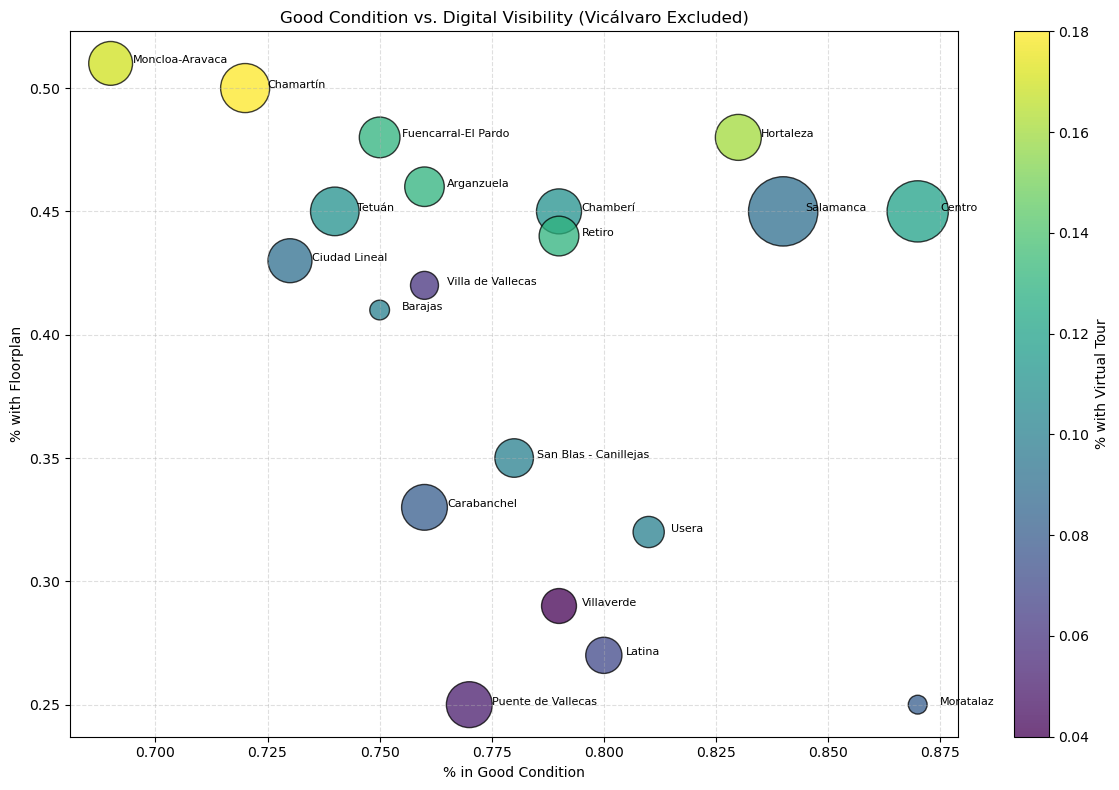

In [59]:
# We filter the DataFrame excluding Vicálvaro because is a measure that makes the scatter less clear.
filtered_summary = district_summary.drop(index='Vicálvaro', errors='ignore')

# Visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    filtered_summary['% in Good Condition'],
    filtered_summary['% with Floorplan'],
    s=filtered_summary['Listings Count'] * 0.4,
    c=filtered_summary['% with Virtual Tour'],
    cmap='viridis',
    edgecolors='k',
    alpha=0.75
)

# Labels by district
for idx, row in filtered_summary.iterrows():
    plt.text(row['% in Good Condition'] + 0.005, row['% with Floorplan'], idx, fontsize=8)


plt.xlabel('% in Good Condition')
plt.ylabel('% with Floorplan')
plt.title('Good Condition vs. Digital Visibility (Vicálvaro Excluded)')
plt.grid(True, linestyle='--', alpha=0.4)


cbar = plt.colorbar(scatter)
cbar.set_label('% with Virtual Tour')

plt.tight_layout()
plt.show()


### Good Condition vs. Digital Visibility

> **Objective:** Identify districts that combine good physical condition with digital visibility (plans and virtual tours).

#### Key observations:

- **Chamartín** and **Moncloa-Aravaca** combine a high percentage of homes in good condition (>70%) with high digitalization (more than 50% with a plan and virtual tour).
- **Centro** and **Salamanca** stand out for their good quality and good digitalization, although they are slightly lower in terms of the percentage of homes with a plan.
- **Moratalaz** stands out with the highest percentage of good condition (>85%) but surprisingly **very low digitalization** (bottom right point): this could be a great opportunity for improvement to gain visibility.
- **Villaverde**, **Puente de Vallecas**, and **Latina** have a good proportion of properties in good condition, but **very low digital visibility**, which may indicate hidden potential.

#### Business Insight:
> **Prioritize districts with high physical quality but low digital presence**, such as Moratalaz, to capture undervalued or uncompetitive properties online.

### 2) District Comparison: Price vs. Average Size
**Objective:** Analyze which districts offer the largest average surface area at the lowest price per square meter.

- X-axis: Average price per square meter
- Y-axis: Average surface area
- Size: Number of listings
- Color: Average rooms

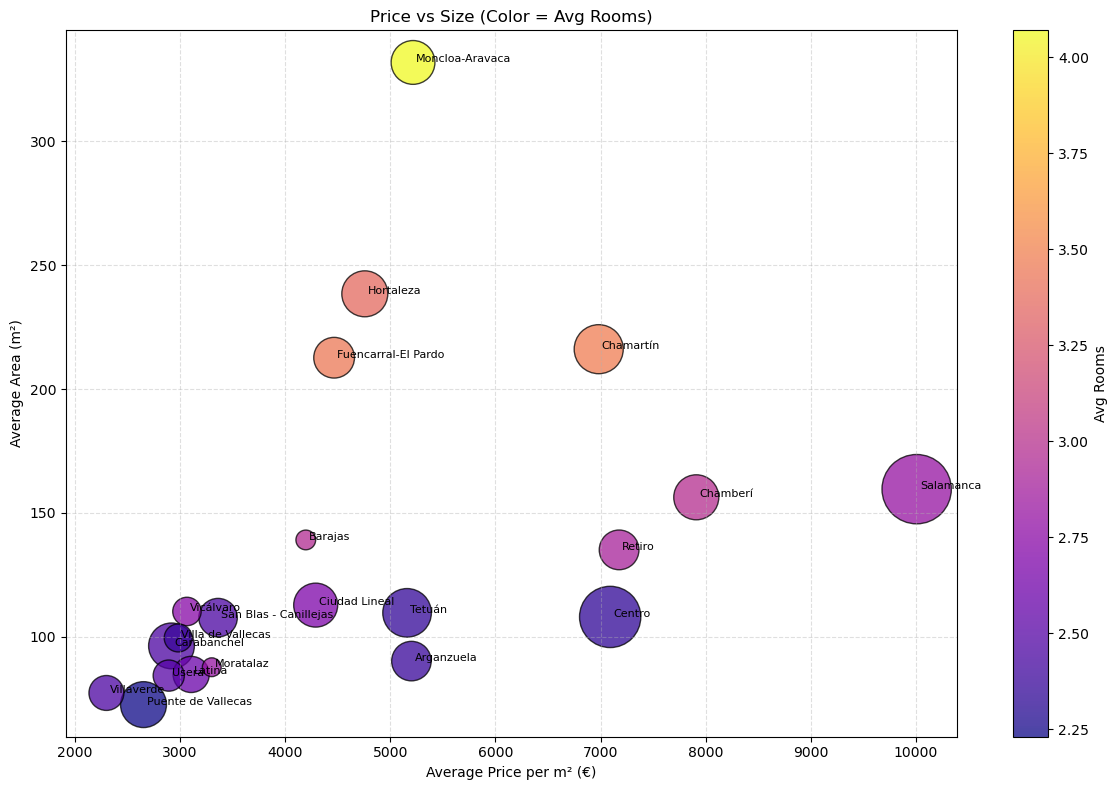

In [62]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    district_summary['Avg €/m²'],
    district_summary['Avg Area (m²)'],
    s=district_summary['Listings Count'] * 0.4,
    c=district_summary['Avg Rooms'],
    cmap='plasma',
    edgecolors='k',
    alpha=0.75
)

for idx, row in district_summary.iterrows():
    plt.text(row['Avg €/m²'] + 30, row['Avg Area (m²)'], idx, fontsize=8)

plt.xlabel('Average Price per m² (€)')
plt.ylabel('Average Area (m²)')
plt.title('Price vs Size (Color = Avg Rooms)')
plt.grid(True, linestyle='--', alpha=0.4)
cbar = plt.colorbar(scatter)
cbar.set_label('Avg Rooms')
plt.tight_layout()
plt.show()


### Price per m² vs. Average Area (Color = Average Rooms)

> **Objective:** To identify areas with the best surface-to-price ratio, adjusted by the number of rooms.

#### Key observations:

- **Moncloa-Aravaca**, **Hortaleza**, and **Fuencarral-El Pardo** have large apartments (>200 m²) and many rooms (>3.5), which justifies their higher prices.
- **Villa de Vallecas**, **Usera**, **Carabanchel**, **Puente de Vallecas**, and **Villaverde** offer a powerful combination:
- Very low prices per m² (<€3,000)
- Decent surface areas (80–110 m²)
- Adequate number of rooms (≈2.5)
- **Retiro**, **Centro**, **Chamberí**, and especially **Salamanca** have the highest prices, although not necessarily with larger surface areas. These are the classic "premium" areas of Madrid.

#### Business Insight:
> **Ideal for investment: districts with good surface area and number of rooms at low prices per m².** Clear examples: Villaverde, Puente de Vallecas, Villa de Vallecas.

### 3) District Comparison: Price vs. Comfort (Elevator)
**Objective:** See if there are districts with a higher percentage of properties with an elevator while maintaining low prices.

- X-axis: Average price per square meter
- Y-axis: % with elevator
- Size: Number of listings
- Color: % in good condition

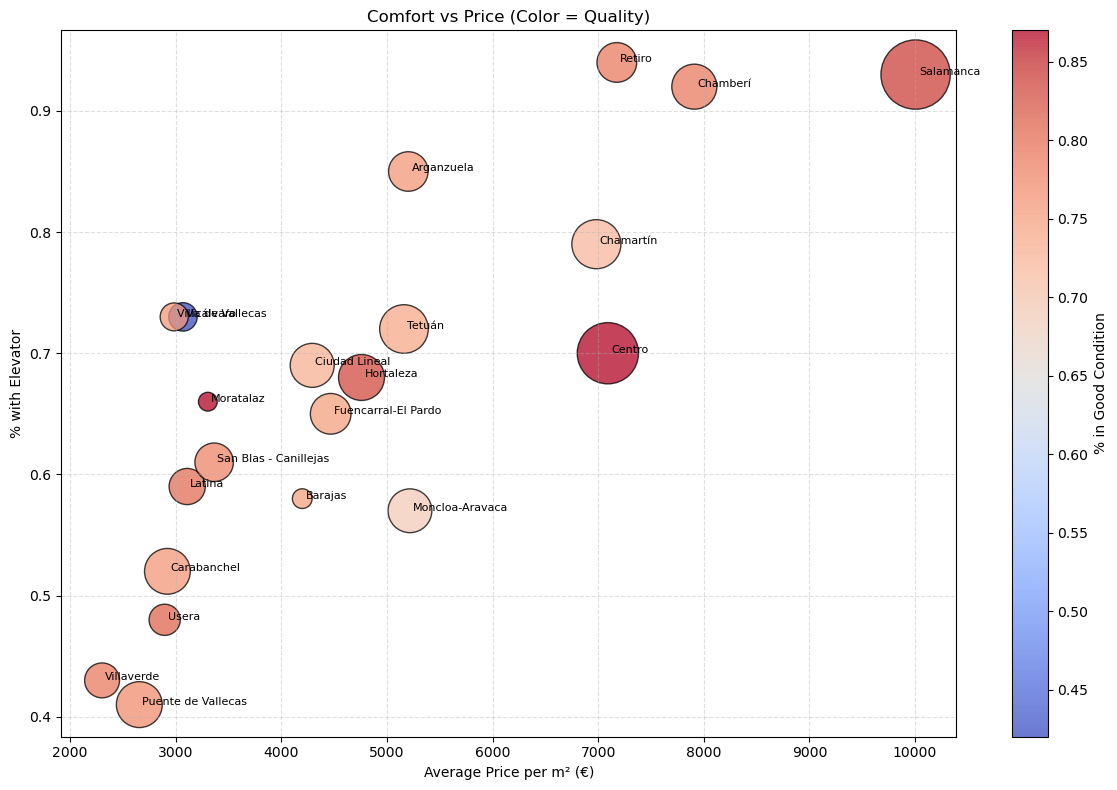

In [65]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    district_summary['Avg €/m²'],
    district_summary['% with Elevator'],
    s=district_summary['Listings Count'] * 0.4,
    c=district_summary['% in Good Condition'],
    cmap='coolwarm',
    edgecolors='k',
    alpha=0.75
)

for idx, row in district_summary.iterrows():
    plt.text(row['Avg €/m²'] + 30, row['% with Elevator'], idx, fontsize=8)

plt.xlabel('Average Price per m² (€)')
plt.ylabel('% with Elevator')
plt.title('Comfort vs Price (Color = Quality)')
plt.grid(True, linestyle='--', alpha=0.4)
cbar = plt.colorbar(scatter)
cbar.set_label('% in Good Condition')
plt.tight_layout()
plt.show()

### Comfort vs. Price (Color = % in Good Condition)

> **Objective:** Find neighborhoods that are comfortable (elevator) and in good condition, without paying premium prices.

#### Key Takeaways:

- **Top quality and comfort (expensive):** Salamanca, Retiro, Chamberí
→ +90% with elevators and very good condition, but very high prices.

- **Ideal Balance:** Arganzuela, Chamartín, Centro
→ Good comfort, many homes in good condition, and more reasonable prices than the top neighborhoods.

- **Growth Potential:** Tetuán, Ciudad Lineal, Fuencarral-El Pardo
→ They combine medium-high quality, intermediate prices, and room for appreciation.

- **Low prices, room for improvement:** Usera, Villaverde, Puente de Vallecas
→ Very low prices, but less comfort. A riskier investment, ideal for renovations.

#### Investment Insight:
> **Best comfort-quality-price ratio in: Chamartín, Arganzuela, and Tetuán.**


## Final Conclusions and Recommended Opportunities

After the full analysis, four opportunity profiles stand out:

- **Bargains (Type A):** undervalued relative to their quality and location.
- **Cheap in an expensive area (Type B):** opportunities within expensive districts.
- **Rental Yield (Type C):** affordable, in good condition, attractive to tenants.
- **Renovable with potential (Type D):** with room for appreciation after renovation.
 

In [68]:
def opportunities_summary(df, tipo, cols, top_n=5):
    df = df.copy()
    df['Tipo'] = tipo
    return df[cols + ['Tipo']].head(top_n)

cols_base = ['district', 'price', 'price_per_m2', 'area', 'n_rooms', 'property_state', 'ad_url', 'latitude', 'longitude']

opportunities = pd.concat([
    opportunities_summary(bargain, 'Absolute Bargains (A)', cols_base),
    opportunities_summary(cheap_in_expensive_area, 'Cheap in an expensive area (B)', cols_base),
    opportunities_summary(rental_yield, 'Rental Yield (C)', cols_base),
    opportunities_summary(renovable, 'Renovable with potential (D)', cols_base)
])

opportunities = opportunities.reset_index(drop=True)

In [69]:
madrid_map = folium.Map(location=[40.4168, -3.7038], zoom_start=11)
bookmarks = MarkerCluster().add_to(madrid_map)

for _, row in opportunities.iterrows():
    if pd.notnull(row.get('latitude')) and pd.notnull(row.get('longitude')):
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            tooltip=f"{row['district']} - {row['Tipo']}",
            popup=f"""
            <b>Precio:</b> {int(row['price']):,} €<br>
            <b>€/m²:</b> {int(row['price_per_m2'])} €<br>
            <b>Habitaciones:</b> {int(row['n_rooms'])}<br>
            <b>Estado:</b> {row['property_state']}<br>
            <a href='{row['ad_url']}' target='_blank'>Ver anuncio</a>
            """,
            icon=folium.Icon(color='green' if 'Chollo' in row['Tipo'] else 'blue')
        ).add_to(bookmarks)

madrid_map

In [70]:
madrid_map.save("mapa_madrid.html")

In [71]:
# --- Feature selection ---
features = [
    'area',
    'n_rooms',
    'n_baths',
    'floor',
    'has_terrace',
    'has_garden',
    'has_elevator',
    'has_floorplan',
    'has_virtual_tour',
    'has_parking',
    'has_swimming_pool',
    'has_energy_certificate',
    'is_exterior',
    'district'
]

# --- Clean & prepare ---
df_model = df_sale.copy()
df_model = df_model.dropna(subset=features + ['price'])  # remove rows with missing features

# Normalize 'is_exterior' to boolean if needed
df_model['is_exterior'] = df_model['is_exterior'].astype(str).str.lower().eq('true')

# Encode categorical variable: 'district'
df_model['district_encoded'] = df_model['district'].astype('category').cat.codes

# Replace 'district' with encoded version
features = [f if f != 'district' else 'district_encoded' for f in features]

# --- Split & train ---
X = df_model[features]
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- Evaluation ---
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:,.2f} €")
print(f"R² Score: {r2:.3f}")


Mean Absolute Error: 82,990.86 €
R² Score: 0.910


### Predictive Model – Estimating Property Prices

As a final step, we built a basic predictive model to estimate the price of a property based on its physical features and location. This serves to:

- Validate the importance of the variables analyzed
- Estimate expected price ranges
- Identify undervalued listings based on predicted vs actual prices

We used a **Random Forest Regressor** with the following features:

- Property characteristics: `area`, `n_rooms`, `n_baths`, `floor`
- Amenities: `has_terrace`, `has_garden`, `has_elevator`
- Digital visibility: `has_floorplan`, `has_virtual_tour`
- Location: encoded `district`
- Orientation: `is_exterior`
- Certification status: `has_energy_certificate`

The model achieved the following performance:

- **Mean Absolute Error (MAE):** 82,990 €  
- **R² Score:** 0.910 (indicates the proportion of price variance explained)

This predictive baseline could be used to flag listings whose real price deviates significantly from the predicted one — a useful tool for surfacing potential investment opportunities.


In [73]:
X_test = X_test.copy()
X_test['price_actual'] = y_test
X_test['price_pred'] = y_pred
X_test['error'] = X_test['price_actual'] - X_test['price_pred']
X_test['error_pct'] = X_test['error'] / X_test['price_pred'] * 100

In [74]:
undervalued = X_test.sort_values(by='error_pct', ascending=True).head(10)

cols_join = ['reference_id', 'ad_url', 'district', 'area', 'n_rooms', 'price', 'price_per_m2', 'property_state']
undervalued = undervalued.merge(df_sale[cols_join], left_index=True, right_index=True, how='left')

### Model-Based Opportunity Detection – Undervalued Listings

Based on the trained model (R² = 0.91), we compared the predicted price to the actual listing price in the test set.

By sorting properties where the actual price is **significantly lower** than the predicted price, we can detect potential investment "sweet spots".

The top 10 undervalued listings show price differences of over 20–30%, even when accounting for structural variables and location.

These properties are not just cheap — they’re cheap **according to the model**, making them prime candidates for deeper due diligence and potential acquisition.


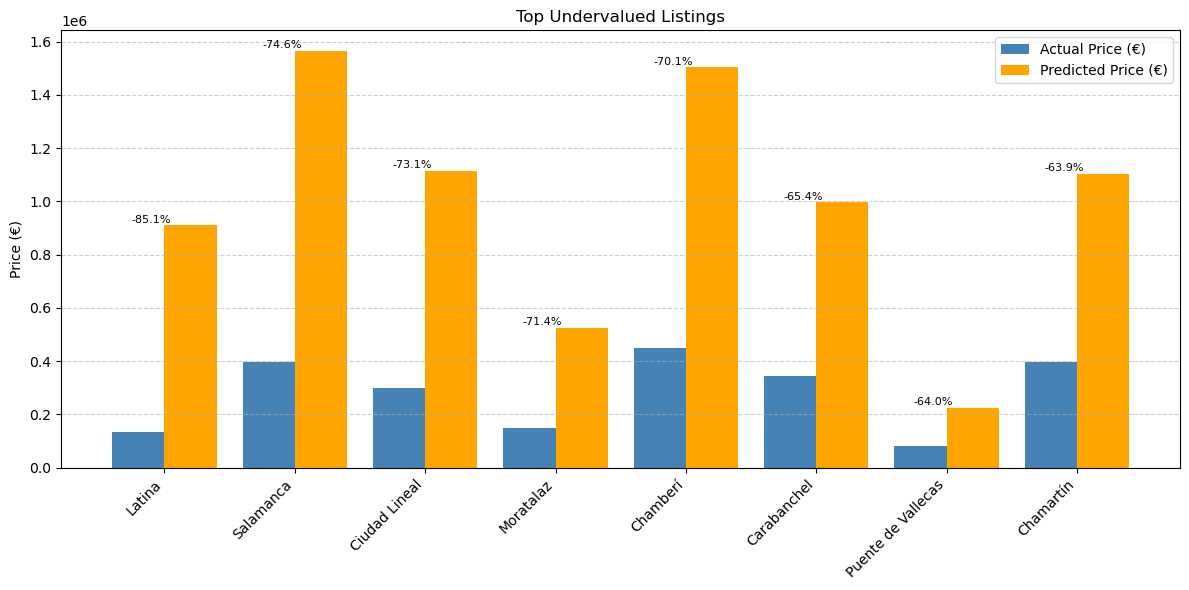

In [76]:
# Eliminate properties with exaggerated predictions
filtered_undervalued = undervalued[
    (undervalued['price_pred'] < 2_000_000) & (undervalued['price_actual'] < 2_000_000)
]

plot_data = filtered_undervalued.sort_values(by='error_pct').head(10)

plt.figure(figsize=(12, 6))
bar_width = 0.4
index = np.arange(len(plot_data))

plt.bar(index, plot_data['price_actual'], bar_width, label='Actual Price (€)', color='steelblue')
plt.bar(index + bar_width, plot_data['price_pred'], bar_width, label='Predicted Price (€)', color='orange')

for i, (actual, pred) in enumerate(zip(plot_data['price_actual'], plot_data['price_pred'])):
    pct = (actual - pred) / pred * 100
    plt.text(i + bar_width / 2 - 0.1, max(actual, pred) + 10000, f"{pct:.1f}%", ha='center', fontsize=8)

plt.xticks(index + bar_width / 2, plot_data['district'], rotation=45, ha='right')
plt.ylabel('Price (€)')
plt.title('Top Undervalued Listings')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

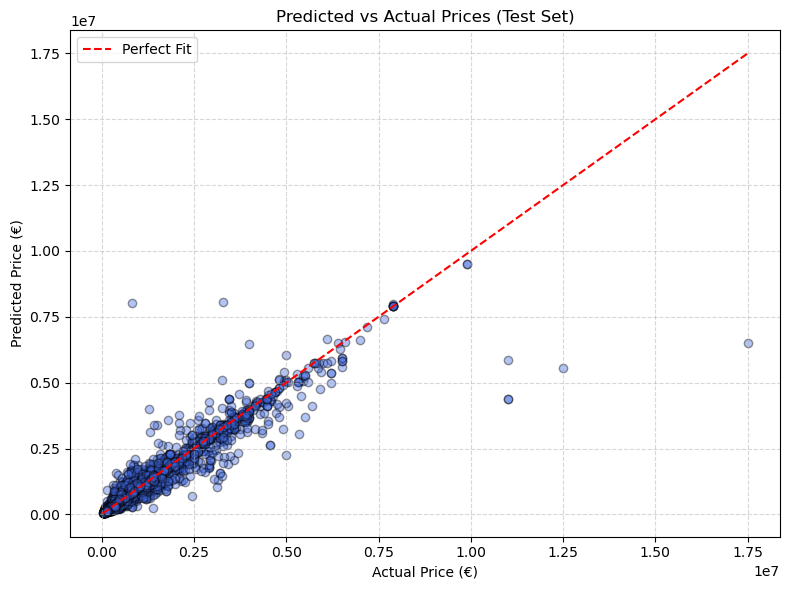

In [77]:
# Validate model quality
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')

plt.xlabel('Actual Price (€)')
plt.ylabel('Predicted Price (€)')
plt.title('Predicted vs Actual Prices (Test Set)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


### Model Validation and Opportunity Detection

To ensure the robustness of the predictive model, we validated its performance by comparing actual vs. predicted prices on the test set.

#### Scatter Plot – Predicted vs. Actual Prices

This plot shows how well the model estimates prices across the dataset:

- Most points cluster around the red diagonal (`Perfect Fit`), indicating strong model accuracy.
- A few outliers remain, which is expected in a market with both luxury properties and undervalued listings.
- The model achieves:
  - **MAE ≈ 83K €**
  - **R² ≈ 0.91**, suggesting it explains over 90% of the variance in prices.

#### Strategic Use of This Model

We filtered listings where the actual price is significantly **lower than the model’s prediction** and excluded extreme outliers.  
This approach helps us flag **data-driven investment opportunities**, not just cheap properties, but those which are **unusually cheap given their features and location**.

Combined with visual, location and quality analyses, this becomes a powerful tool for identifying potential deals.


### Visual Analysis – Model-Detected Undervalued Properties

The chart below shows the top 10 listings where the actual sale price is significantly lower than the model-predicted value, based on the Random Forest trained on structural and location features.

- Blue bars represent the **actual listing price**
- Orange bars show the **model’s predicted price**
- Percentage above each group represents the deviation

These properties stand out as statistically undervalued — not just cheap in absolute terms, but unusually low **given their size, features and location**.


## Summary – Investment Insights for Rapada Partners

After a comprehensive analysis of over 48,000 property listings in the city of Madrid, we identified four key types of high-potential investment opportunities.

---

### 1. Strategic Opportunity Types

The portfolio of investment-ready listings was classified into four categories, each offering a different kind of return potential:

- **Bargains (Type A):** Properties that are significantly undervalued compared to their condition, size, and features.
- **Cheap in an expensive area (Type B):** Listings priced well below the average €/m² within high-value districts.
- **Rental Yield (Type C):** Affordable, well-equipped properties ideal for long-term rental investment.
- **Renovable with potential (Type D):** Properties in need of renovation but located in districts with strong value appreciation.

---

### 2. Recommended Districts

Cross-referencing quality, digital visibility, surface area, and €/m² value, we recommend focusing on:

- **Villaverde, Puente de Vallecas, Carabanchel:** High-volume, lower-cost zones with consistent good condition scores.
- **Chamartín, Moncloa-Aravaca, Retiro:** Premium districts with margin for repositioning and resale.
- **Moratalaz and Ciudad Lineal:** Strong property condition but lower digital exposure—great for under-the-radar acquisitions.

---

### 3. Suggested Next Steps

- Review and analyze the **20 highlighted listings** across the 4 opportunity types (interactive map).
- Align acquisition strategy depending on the risk/return profile of the fund:
  - Conservative → Focus on Type C
  - Opportunistic → Prioritize Type A and D
